In [ ]:
#To import your dataset
import kagglehub
import shutil
import os
#Replace with your dataset requirments
path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")

# Define your custom save location
custom_path = "/content/Project/fruits_dataset"

# Move only the dataset contents
if not os.path.exists(custom_path):
    shutil.copytree(internal_dataset_path, custom_path)

print("Dataset moved to:", custom_path)


In [ ]:
#installing tensorflow
pip install -q tensorflow[and-cuda]

In [ ]:
#Verifying installation
import tensorflow as tf
tf.__version__

'2.20.0-dev20250412'

In [ ]:
#required libraries/Modules for Image processing in tensorflow and V3 Inception
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3

from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np

In [ ]:
#Defining and resizing the image
IMAGE_SIZE = [224, 224]

train_path = '/content/Project/dataset/dataset/train'
valid_path = '/content/Project/dataset/dataset/test'

In [ ]:
inception = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [ ]:
for layer in inception.layers:
    layer.trainable = False

In [ ]:

import os
folders = os.listdir('/content/Project/dataset/dataset/train')
prediction = Dense(len(folders), activation='softmax')(x)

In [ ]:
x = Flatten()(inception.output)

In [ ]:
prediction = Dense(len(folders), activation='softmax')(x)
model = Model(inputs=inception.input, outputs=prediction)
model.summary()

In [ ]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [ ]:
#testing and training images resizing and formatting .
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
training_set = train_datagen.flow_from_directory('/content/Project/dataset/dataset/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 10901 images belonging to 6 classes.


In [ ]:
test_set = test_datagen.flow_from_directory('/content/Project/dataset/dataset/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 2698 images belonging to 6 classes.


In [ ]:
#Training and Validating image

r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=10,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 232s 629ms/step - accuracy: 0.8491 - loss: 1.5890 - val_accuracy: 0.9666 - val_loss: 0.2264
Epoch 2/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 195s 571ms/step - accuracy: 0.9645 - loss: 0.3604 - val_accuracy: 0.9678 - val_loss: 0.4107
Epoch 3/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 173s 488ms/step - accuracy: 0.9720 - loss: 0.2756 - val_accuracy: 0.9848 - val_loss: 0.1481
Epoch 4/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 163s 478ms/step - accuracy: 0.9790 - loss: 0.2739 - val_accuracy: 0.9837 - val_loss: 0.2128
Epoch 5/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 201s 476ms/step - accuracy: 0.9839 - loss: 0.1787 - val_accuracy: 0.9870 - val_loss: 0.1826
Epoch 6/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 171s 500ms/step - accuracy: 0.9834 - loss: 0.2443 - val_accuracy: 0.9826 - val_loss: 0.2540
Epoch 7/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 164s 480ms/step - accuracy: 0.9872 - loss: 0.1832 - val_accuracy: 0.9844 - val_loss: 0.3075
Epoch 8/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 165s 483ms/step - accuracy: 0.9875 -

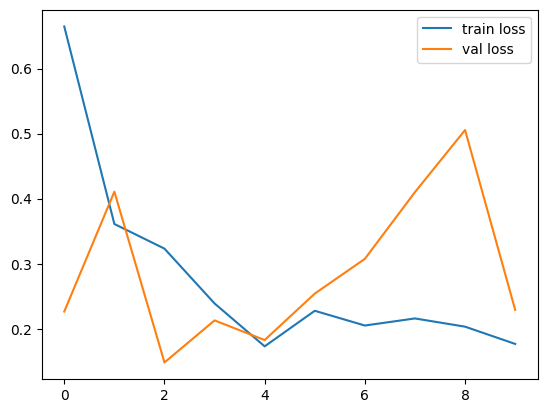

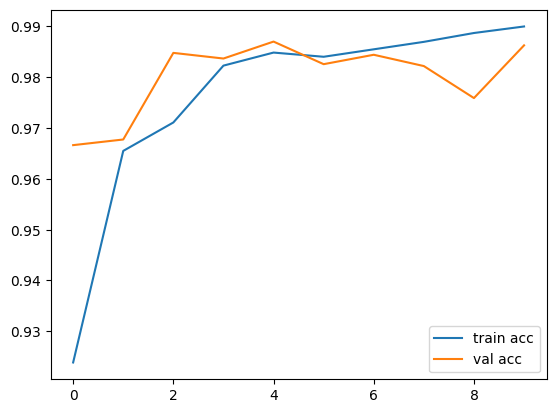

<Figure size 640x480 with 0 Axes>

In [ ]:
#for graphical representation of the result of accuracy and loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [ ]:
#Saving model for future use Case
from tensorflow.keras.models import load_model
model.save('model_inception.h5')

In [ ]:
#Using the trained model to use the webcam for testing 
import tensorflow as tf
import numpy as np
from PIL import Image
import cv2
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

model = load_model('model_inception.h5')


def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();


      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);


      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename


def preprocess_image(image_path):
  img = Image.open(image_path)
  img = img.resize((224, 224))
  img_array = np.array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)
  return img_array


try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  preprocessed_image = preprocess_image(filename)


  predictions = model.predict(preprocessed_image)


  predicted_class = np.argmax(predictions)


  class_labels = list(training_set.class_indices.keys())
  predicted_label = class_labels[predicted_class]


  print("Predicted class:", predicted_label)

except Exception as err:
  print(str(err))


NameError: name 'load_model' is not defined